# $\mathcal{G}_{\phi, \psi}$ 



In [1]:
pwd

'/data1/kishoretarafdar/src.port/NSLI.v00'

In [2]:
!python --version

Python 3.12.7


GPU availability?

In [3]:
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)

2025-06-06 22:14:52.671520: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749228292.693785 3427612 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749228292.700673 3427612 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-06 22:14:52.725418: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3


3

Select one GPU

        Restrict code to use a particular GPU...

In [4]:
# # include ../dirx 
mylibpath = [
    '/home/kishoretarafdar/bin'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu

In [5]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# select_gpu = gpus[gpu_id]
memory_limit = 48 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

3 Physical GPUs available 
Selected 1 Logical GPU with 48 GB memory limit


I0000 00:00:1749216557.884190 3391554 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 49152 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [ ]:
# !nvidia-smi

In [ ]:
49140//1024

47

In [ ]:
# # gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#   # Restrict TensorFlow to only allocate 1GB of memory on the first GPU
#   try:
#     _limitGB = 32
#     memory_limit = int(_limitGB*1024)
#     tf.config.set_logical_device_configuration(
#         gpus[0], 
#         [tf.config.LogicalDeviceConfiguration(memory_limit=memory_limit)])
#     logical_gpus = tf.config.list_logical_devices('GPU')
#     print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
#   except RuntimeError as e:
#     # Virtual devices must be set before GPUs have been initialized
#     print(e)


In [ ]:
# !python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"

In [ ]:
# pip install tqdm
# pip install scikit-learn
# pip install scikit-image
# pip install nibabel
# pip install matplotlib

In [ ]:
# import tensorflow as tf
import keras
# from wavetf import WaveTFFactory
# import tensorflow_wavelets.Layers.DWT as DWT
# import tensorflow_addons as tfa
from tensorflow.keras.layers import Concatenate
from keras.utils import plot_model 
import time
# import pywt
from tqdm import tqdm 
import numpy as np
import nibabel as nib

from keras.utils import to_categorical
import matplotlib.pyplot as plt
from IPython import display



        load attention and DWT modules..

In [ ]:
# # include ../dirx 
mylibpath = [
    # '/home/kishor/src/FastDWTConvLayers',
    # '/home/kishor/src/MRSegmentation/Attentions19102023'
      # '/home/k/src/_MEDCNNsrc_part/MEDCNN_copy'
      '/home/kishoretarafdar/src/MEDCNN_copy'
      
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath

from utils import elapsedtime, timestamp
from BoundaryAwareDiceLoss import BoundaryAwareDiceLoss
# from dice import dice_coef
from Load2Ddata import load_ibsr_XY
from TTViterators import get_train_test_val_iterators

# # from DWTIDWT2Dtfv1 import DWT2D, IDWT2D
# from TFDWT3D.DWTIDWT2Dtfv1 import DWT2D, IDWT2D
# from DWTselfAttention2D import DWTselfAttention
# from tensorflow.keras.layers import Concatenate



In [ ]:
ls /home/kishoretarafdar/

bin/               miniconda.readme         src/
micromamba.readme  passwordlessauth.readme  vscode_debug.log


In [ ]:
start_time=time.time()

# Time elapsed
end_time = time.time()
print(elapsedtime(start_time, end_time))
del start_time, end_time

Elapsed time: mm:ss:mss 	 00:00:000
00:00:000


In [ ]:
timestamp(time.time())

2025-06-06 18:59:22.838267


'20250606'

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

IoU as loss (approx.)  $IoU'=\frac{|T*P|}{|T+P-(T*P)|}=\frac{I}{U}$

$Dice=\frac{2*Intersection}{Union+Intersection}$

Boundary aware dice loss



---

# Data loader

## Option 3 Load complete IBSR

Actual training data

In [ ]:
pwd

'/data1/kishoretarafdar/src2D/G_/models'

In [ ]:
ls /data1/kishoretarafdar/FILESHARE/IBSR_cookedXY_allplanes/IBSR_XY_skullstripping

IBSR_X.npy*  IBSR_Y.npy*


In [ ]:
datapath = '/data1/kishoretarafdar/FILESHARE/IBSR_cookedXY_allplanes/IBSR_XY_skullstripping'
X, Y, dataset = load_ibsr_XY(datapath)
X.shape, Y.shape, dataset

((7056, 256, 256, 1), (7056, 256, 256, 1), 'IBSR')

In [ ]:
# # IBSR_allplanes_shuffled_resized_INPUTS_SS.npy 
# # IBSR_allplanes_shuffled_resized_TARGETS_SS.npy
# import os
# import numpy as np
# # datapath = '/home/k/LOTUS/DATAMRI/IBSR_cooked_XY_SkullStripping'
# # datapath = '/home/kishor/FILESHARE/IBSR_cookedXY_allplanes/IBSR_XY_skullstripping/'
# datapath = '/data1/kishoretarafdar/FILESHARE/IBSR_cookedXY_allplanes/IBSR_XY_skullstripping'
# # with open('IBSR_allplanes_shuffled_resized_INPUTS_SS.npy', 'rb') as f:
# with open(os.path.join(datapath, 'IBSR_X.npy'), 'rb') as f:
#     X = np.load(f)
# del f
# # with open('IBSR_allplanes_shuffled_resized_TARGETS_SS.npy', 'rb') as f:
# with open(os.path.join(datapath, 'IBSR_Y.npy'), 'rb') as f:
#     Y = np.load(f)
# del f, datapath
# dataset = 'IBSR'
# X.shape, Y.shape

In [ ]:
# X, Y = X[0:88,...], Y[0:88,...]

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

## Option 3: Load ATLAS2 (new)

In [ ]:
atlaspath = '/data1/kishoretarafdar/DATASETS.port/ATLAS2XY'

In [ ]:
ls $atlaspath

ATLAS_X_minnorm40.npy  ATLAS_Y_minnorm40_int8.npy


In [ ]:
import os
import numpy as np
with open(os.path.join(atlaspath, 'ATLAS_X_minnorm40.npy'), 'rb') as f:
    X = np.load(f)
del f 
with open(os.path.join(atlaspath, 'ATLAS_Y_minnorm40_int8.npy'), 'rb') as f:
    Y = np.load(f)
del f
dataset = 'ATLAS'
X.shape, Y.shape 

((24647, 256, 256, 1), (24647, 256, 256, 1))

In [ ]:
# X = X[0:11111,...]
# Y = Y[0:11111,...]
X.shape, Y.shape

((24647, 256, 256, 1), (24647, 256, 256, 1))

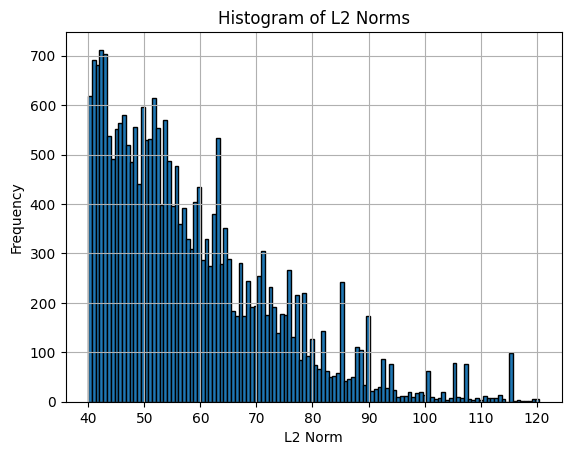

In [ ]:
# Compute L2 norms for all slices
l2_norms = [np.linalg.norm(Y[k,...]) for k in range(Y.shape[0])]

# Plot histogram
plt.hist(l2_norms, bins=120, edgecolor='black')
plt.title('Histogram of L2 Norms')
plt.xlabel('L2 Norm')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
del l2_norms

keeping only those slices whose mask's l2 norm is > 20

In [ ]:
# margin = 20 ##!! 
# keepindices = []
# for k in range(Y.shape[0]):
#     l2_norm = np.linalg.norm(Y[k,...])
#     if l2_norm < margin:
#         continue
#     keepindices.append(k)
# print(len(keepindices))


In [ ]:
# X_l2filt = X[keepindices]
# Y_l2filt = Y[keepindices] 
# X_l2filt.shape, Y_l2filt.shape

In [ ]:
# k = np.random.randint(X_l2filt.shape[0])
# plt.subplot(131), plt.imshow(X_l2filt[k,...]), plt.title(f'slice {k}')
# plt.subplot(132), plt.imshow(Y_l2filt[k,...])
# plt.subplot(133), plt.imshow(X_l2filt[k,...]*Y_l2filt[k,...])

In [ ]:
# X, Y = X_l2filt, Y_l2filt
# del X_l2filt, Y_l2filt
# X.shape, Y.shape

In [ ]:
Xbak, Ybak = X, Y
X[0:1800,...].shape, Y[0:1800,...].shape

((1800, 256, 256, 1), (1800, 256, 256, 1))

In [ ]:
X, Y = X[0:1800,...],Y[0:1800,...]

In [ ]:
# X, Y = Xbak, Ybak 

## Train Test split

In [ ]:
N = 64
Xrez = tf.keras.layers.Resizing(
                    height=N,
                    width=N,
                    interpolation='bilinear',
                    crop_to_aspect_ratio=False
                )(X)
Yrez = tf.keras.layers.Resizing(
                    height=N,
                    width=N,
                    interpolation='bilinear',
                    crop_to_aspect_ratio=False
                )(Y)

train_iterator, test_iterator, val_iterator = get_train_test_val_iterators(Xrez.numpy(),Yrez.numpy())
Xrez.shape, Yrez.shape

2025-06-06 18:59:59.377195: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 48.00GiB (51539607552 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


(TensorShape([24647, 64, 64, 1]), TensorShape([24647, 64, 64, 1]))

In [ ]:
# from TTViterators import get_train_test_val_iterators
train_iterator, test_iterator, val_iterator = get_train_test_val_iterators(X,Y)

True (1440, 256, 256, 1)
(1440, 256, 256, 1) (1440, 256, 256, 1) float32 int8 <class 'numpy.ndarray'> <class 'numpy.ndarray'> (360, 256, 256, 1) (360, 256, 256, 1) float32 int8 <class 'numpy.ndarray'> <class 'numpy.ndarray'>
Train  True (1296, 256, 256, 1) False float32
Val    True (144, 256, 256, 1) False float32
Test.  True (360, 256, 256, 1) False float32


In [ ]:
# tmp
# from TTViterators import get_train_test_val_iterators
train_iterator, test_iterator, val_iterator = get_train_test_val_iterators(X[0:6,40:72,40:72,:],Y[0:6,40:72,40:72,:])

True (4, 32, 32, 1)
(4, 32, 32, 1) (4, 32, 32, 1) float32 float32 <class 'numpy.ndarray'> <class 'numpy.ndarray'> (2, 32, 32, 1) (2, 32, 32, 1) float32 float32 <class 'numpy.ndarray'> <class 'numpy.ndarray'>
Train  True (3, 32, 32, 1) True float32
Val    True (1, 32, 32, 1) True float32
Test.  True (2, 32, 32, 1) True float32


In [ ]:
# train_iterator, test_iterator, val_iterator = get_train_test_val_iterators(Xrez.numpy(),Yrez.numpy())

In [ ]:
# train_iterator, test_iterator, val_iterator = get_train_test_val_iterators(Xrez[0:6,:,:,:].numpy(),Yrez[0:6,:,:,:].numpy())


In [ ]:
# # Train test split
# # import tensorflow as tf
# # import os
# # import numpy as np
# # from tqdm import tqdm 
# # from skimage.io import imread, imshow
# #from skimage.transform import resize
# from sklearn.model_selection import train_test_split
# # import matplotlib.pyplot as plt
# # In[61]:

# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# print(X_train.shape==Y_train.shape, X_train.shape)
# del X, Y
# X_train.shape, Y_train.shape, X_train.dtype, Y_train.dtype, type(X_train), type(Y_train), X_test.shape, Y_test.shape, X_test.dtype, Y_test.dtype, type(X_test), type(Y_test)

In [ ]:
# # Validation split
# from sklearn.model_selection import train_test_split
# X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42) # 0.25 x 0.8 = 0.2
# print('Train ', X_train.shape==Y_train.shape, X_train.shape, X_train.dtype==Y_train.dtype, X_train.dtype)
# print('Val   ', X_val.shape==Y_val.shape, X_val.shape, X_val.dtype==Y_val.dtype, X_val.dtype)
# print('Test. ', X_test.shape==Y_test.shape, X_test.shape, X_test.dtype==Y_test.dtype, X_test.dtype)

In [ ]:
# np.max(X_train), np.min(X_train), np.max(Y_train), np.min(Y_train)

In [ ]:
# # Normalization (assumned inside model)
# datagen = tf.keras.preprocessing.image.ImageDataGenerator(...)
# datagen.fit(X_train)

In [ ]:
# batch_size = 20
# train_iterator = datagen.flow(X_train, Y_train, batch_size=batch_size)
# val_iterator = datagen.flow(X_val, Y_val, batch_size=batch_size)
# test_iterator = datagen.flow(X_test, Y_test, batch_size=batch_size)

or, to categorical (multiclass segmentation with $softmax$ in the last layer)

In [ ]:
# ## new categorical
# from keras.utils import to_categorical

# # Assuming Y_train is a 1D array containing class labels
# # Convert Y_train to categorical format
# Y_train_categorical = to_categorical(Y_train)
# del Y_train
# Y_val_categorical = to_categorical(Y_val)
# del Y_val
# Y_test_categorical = to_categorical(Y_test)
# del Y_test

# batch_size = 20
# train_iterator = datagen.flow(X_train, Y_train_categorical, batch_size=batch_size)
# val_iterator = datagen.flow(X_val, Y_val_categorical, batch_size=batch_size)
# test_iterator = datagen.flow(X_test, Y_test_categorical, batch_size=batch_size)
# del to_categorical

In [ ]:
# del Y_train_categorical, Y_test_categorical, Y_val_categorical
# del X_train, X_test, X_val
# del datagen

In [ ]:
break

In [ ]:
# next(train_iterator).shape

# Load and compile model

In [ ]:
# from modelAPS import GφψAPS, configs

In [ ]:
# from modelrec import Gφψ, configs

In [ ]:
# cd /data1/kishpretarafdar/

In [ ]:
# cd ..

In [ ]:
# from modelrational import GφψAPS, configs

2024-11-02 18:46:24.169592: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1566] failed to allocate 48.00GiB (51539607552 bytes) from device: CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
# from modelrational_wavelettfofwts import GφψAPS, configs

2024-11-02 22:19:49.287351: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1566] failed to allocate 48.00GiB (51539607552 bytes) from device: CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
# from modelrational_wavelettfofwts import Unet2Dwaveletconv as GφψAPS
# from modelrational_wavelettfofwts import configs

2024-11-02 19:54:21.784702: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1566] failed to allocate 48.00GiB (51539607552 bytes) from device: CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
# from models.U_DWTofWeights_method1_encoderconv import Unet2Dwaveletconv as GφψAPS
# from models.U_DWTofWeights_method1_encoderconv import configs

2024-11-03 00:21:53.726991: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1566] failed to allocate 48.00GiB (51539607552 bytes) from device: CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
# from models.correctmetod1_encoderconv import Unet2Dwaveletconv as GφψAPS
# from models.correctmetod1_encoderconv import configs


2024-11-03 02:16:03.243519: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1566] failed to allocate 48.00GiB (51539607552 bytes) from device: CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
# from models.correctmetod1_encoderconv import GφψAPS, configs
# from models.correctmetod1_encoderconv import configs


---

In [ ]:
# from models.U_fftconv import Unet2d as GφψAPS
# from models.U_fftconv import configs

2024-11-03 02:29:05.999808: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1566] failed to allocate 48.00GiB (51539607552 bytes) from device: CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
cd model.ckpt

/data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt


In [ ]:
pwd

'/data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt'

In [ ]:
ls

In [ ]:
mylibpath = [
    # '/data1/kishoretarafdar/src2D/G_',
    # '/home/kishoretarafdar/src/MEDCNN_copy',
    '/data1/kishoretarafdar/src.port/NSLI.v00/utils.Volterra'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath
from NLSI2DVolterrav0 import NLSI2DVolterra

In [ ]:
#%%
def conv2D(
    filters,
    x,
    kernel_size=(3,3), 
    kernel_initializer='he_normal', 
    # activation='relu', 
    padding='same', 
    dropout=0.1):
    """FIR 2D filter and analytic activation"""
    q = tf.keras.layers.Conv2D(
        filters, 
        kernel_size=kernel_size, 
        # activation=activation, 
        kernel_initializer=kernel_initializer, 
        padding=padding)(x)
    q = tf.keras.layers.Dropout(dropout)(q)
    q = tf.keras.layers.Conv2D(
        filters, 
        kernel_size=kernel_size, 
        # activation=activation, 
        kernel_initializer=kernel_initializer, 
        padding=padding)(q)
    return q

In [ ]:
import tensorflow as tf

configs = {
    '5678':(32,64,128,256),
    '4567':(16,32,64,128),
    '3456':(8,16,32,64),
    '2345':(4,8,16,32),
    '1234':(2,4,8,16),
    '2222':(4,4,4,4),
    '1111':(2,2,2,2),
    # '2345':(4,8,16,32),
    # '3456':(8,16,32,64),
    # '4567':(16,32,64,128),
    # '5678':(32,64,128,256),
    # '6789':(64,128,256,512) #issue in GPU memory
    }    
    
    #a,b,c,d,e=2,4,8,16,32
    # a,b,c,d,e=4,8,16,32,64
    # a,b,c,d,e=8,16,32,64,128
    # a,b,c,d,e=16,32,64,128,256

def Unet2d(
    n_classes=2, 
    n_input_channels=1, 
    scale=1, 
    input_shape =(256, 256, 1),
    # dataset='IBSR', 
    # config=configs['12345'],
    config=configs['4567'],
    loss = 'binary_crossentropy',
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    residual=False,
    compile=True):

    a, b, c, d = config

    
    #inputs = tf.keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    # inputs = tf.keras.layers.Input((256, 256, 1))
    # s=inputs
    inputs = tf.keras.layers.Input(input_shape)
    # s = tf.keras.layers.Resizing(
    #                 height=256,
    #                 width=256,
    #                 interpolation='bilinear',
    #                 crop_to_aspect_ratio=False
    #             )(inputs)


    s = inputs
    s = tf.keras.layers.Lambda(lambda x: x / 255)(s)
    # s = tf.keras.layers.Lambda(lambda x: tf.where(
    #     tf.reduce_sum(x) !=0,
    #     (((x - tf.reduce_mean(x)) / tf.math.reduce_std(x)) - (tf.reduce_min((x - tf.reduce_mean(x)) / tf.math.reduce_std(x)))) 
    #    / ((tf.reduce_max((x - tf.reduce_mean(x)) / tf.math.reduce_std(x))) - (tf.reduce_min((x - tf.reduce_mean(x)) / tf.math.reduce_std(x)))), 
    #     x
    #     ))(s)
    #s = Normlayer(inputs_resiz)

    #resize
    #inputs_resized = tf.keras.layers.Resizing(
    #    height=256,
    #    width=256,
    #    interpolation='bilinear',
    #    crop_to_aspect_ratio=False
    #)(inputs)


    #s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)

    #a,b,c,d,e=2,4,8,16,32
    # a,b,c,d,e=4,8,16,32,64 ##it was here
    # a,b,c,d,e=8,16,32,64,128
    # a,b,c,d,e=16,32,64,128,256
    #Contraction path
    c1 = conv2D(a,s)
    # c1 = tf.keras.layers.Dropout(0.1)(c1)
    # c1 = tf.keras.layers.Conv2D(a, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    # p1 = c1
    # p1, _p1indices = APSDown()(c1) 

    c2 = conv2D(b, p1)
    # c2 = tf.keras.layers.Dropout(0.1)(c2)
    # c2 = tf.keras.layers.Conv2D(b, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    # p2 = c2
    # p2, _p2indices = APSDown()(c2) 
    
    c3 = conv2D(c, p2)
    c3 = NLSI2DVolterra(filters=c3.shape[-1])(c3)
    # c3 = tf.keras.layers.Dropout(0.2)(c3)
    # c3 = tf.keras.layers.Conv2D(c, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    # p3, _p3indices = APSDown()(c3)
    # p3 = c3 
    
    c4 = conv2D(d, p3)
    c4 = NLSI2DVolterra(filters=c4.shape[-1])(c4)
    # c4 = NLSI2DVolterra(filters=p3.shape[-1])(p3)
    # c4 = tf.keras.layers.Dropout(0.2)(c4)
    # c4 = tf.keras.layers.Conv2D(d, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    # p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    
    #bottom
    # c5 = NLSI2DVolterra(filters=p3.shape[-1])(p4)
    # c5 = conv2D(int(d*2), p4)
    # u4u = tf.keras.layers.Conv2DTranspose(d, (2, 2), strides=(2, 2), padding='same')(c5)
    # u4u = tf.keras.layers.concatenate([u4u, c4])
    # c4u = conv2D(d, u4u)
    # c4u = NLSI2DVolterra(filters=c4u.shape[-1])(c4u)
    # c5 = tf.keras.layers.Conv2D(e, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    #c5 = tf.keras.layers.Dropout(0.3)(c5)
    #c5 = tf.keras.layers.Conv2D(e, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path 
    # u6 = APSUp(_p3indices)(c4,_p3indices) 
    # c6 = conv2Du(c,c4)
    u6 = tf.keras.layers.Conv2DTranspose(c, (2, 2), strides=(2, 2), padding='same')(c4)
    u6 = tf.keras.layers.concatenate([u6, c3])
    # u6 = NLSI2DVolterra(filters=u6.shape[-1])(u6)
    c6 = conv2D(c, u6)
    # c6 = tf.keras.layers.Dropout(0.2)(c6)
    # c6 = tf.keras.layers.Conv2D(c, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    
    # u7 = APSUp(_p2indices)(c6,_p2indices)
    # c7 = conv2Du(b,c6)
    u7 = tf.keras.layers.Conv2DTranspose(b, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c2])
    c7 = conv2D(b, u7)
    # c7 = tf.keras.layers.Dropout(0.2)(c7)
    # c7 = tf.keras.layers.Conv2D(b, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    
    # u8 = APSUp(_p1indices)(c7,_p1indices)
    # c8 = conv2Du(a,c7)
    u8 = tf.keras.layers.Conv2DTranspose(a, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c1])
    c8 = conv2D(a, u8)
    # c8 = tf.keras.layers.Dropout(0.1)(c8)
    # c8 = tf.keras.layers.Conv2D(a, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    
    # u9 = tf.keras.layers.Conv2DTranspose(a, (2, 2), strides=(2, 2), padding='same')(c8)
    # u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    # c9 = tf.keras.layers.Conv2D(a, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    # c9 = tf.keras.layers.Dropout(0.1)(c9)
    # c9 = tf.keras.layers.Conv2D(a, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    # out_resiz  = tf.keras.layers.Resizing(
    #                 height=256,
    #                 width=192,
    #                 interpolation='bilinear',
    #                 crop_to_aspect_ratio=False
    #             )(c9)

    # out_resiz=c9
    # outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(out_resiz)

    R = c8
    if residual==True:
        R = tf.keras.layers.Concatenate()([s, R])
    R = tf.keras.layers.Conv2D(n_classes, (1, 1), activation="softmax")(R)
    outputs = R

     
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])


    if compile==True:
        # model = tf.keras.Model(inputs=[inputs], outputs=[x])
        # generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
        # model.compile(optimizer=generator_optimizer, loss=generator_loss)
       
        model.compile(optimizer=optimizer, loss=loss)
        return model
        #
    else: 
        return model












In [ ]:
# CONFIGKEY= '4567'
CONFIGKEY= '3456'
CONFIGKEY= '2345'
# # CONFIGKEY= '1111'
# CONFIGKEY= '2222'
# CONFIGKEY= '1234'


model, segconfig = Unet2d(
    input_shape =(N, N, 1), 
    config=configs[CONFIGKEY], 
    compile=False), 'nonResidual' 
# model, segconfig = Gφψ(config=configs[CONFIGKEY], compile=False), 'nonResidual' 
# model, lossname = compile_model(model, dataset)

(None, 16, 16, 16)
+ (None, 16, 16, 16, 16, 16)
h1 h2 out (None, 16, 16, 16) (None, 16, 16, 16, 16, 16)
h2_out shape update (None, 16, 16, 16)
(None, 8, 8, 32)
+ (None, 8, 8, 8, 8, 32)
h1 h2 out (None, 8, 8, 32) (None, 8, 8, 8, 8, 32)
h2_out shape update (None, 8, 8, 32)


In [ ]:
#%% compile
# include ../dirx 
mylibpath = [
    # '/data1/kishoretarafdar/src2D/G_',
    # '/home/kishoretarafdar/src/MEDCNN_copy',
    '/data1/kishoretarafdar/src3D/utils'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath


import tensorflow as tf
from tensorflow.keras.utils import plot_model # type: ignore
# from GLosses import BoundaryAwareDiceLoss#, custom_BAD_loss
from GDice import dice_coef
from GMetrics import DiceMetric, IoUMetric

# Loss, lossname = tf.keras.losses.BinaryCrossentropy(), 'bce'
# Loss, lossname = tf.keras.losses.CategoricalCrossentropy(), 'cce'

Loss, lossname = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=False,
    alpha=0.25,
    gamma=2.0,
    from_logits=False,
    label_smoothing=0.0,
    axis=-1,
    reduction='sum_over_batch_size',
    name='binary_focal_crossentropy'
), 'bfc'

# Loss, lossname = tf.keras.losses.CategoricalFocalCrossentropy(
#     alpha=class_weights,#0.25,
#     gamma=2.0,
#     from_logits=False,
#     label_smoothing=0.0,
#     axis=-1,
#     reduction='sum_over_batch_size',
#     name='categorical_focal_crossentropy'
# ), 'cfc'


# Loss, lossname = BoundaryAwareDiceLoss(alpha=1, beta=1, gamma=1, epsilon=1e-5), 'bad' ## BAD loss
# Loss = DiceBCELoss(dice_weight=0.5, bce_weight=0.5)

# Loss, lossname = BoundaryAwareDiceLoss(alpha=1, beta=1, gamma=1, epsilon=1e-5), 'bad' ## BAD loss
# Loss, lossname = 'binary_crossentropy', 'bce'

 # tf.keras.losses.Dice(
    # reduction='sum_over_batch_size', name='dice'
    # )

# Loss = tf.keras.losses.binary_crossentropy(
#     y_true, y_pred, from_logits=False, label_smoothing=0.0, axis=-1
#     )
# 
# Loss = tf.keras.losses.Dice()
# Loss = tf.keras.losses.Dice()  +  tf.keras.losses.BinaryCrossentropy()


# Loss = BoundaryAwareDiceLoss()
# Loss = custom_BAD_loss()
    # reduction='sum_over_batch_size', name='dice'
# )
# def compile_model(model, Loss, learning_rate=0.001):
#     # Loss, lossname, learning_rate, metrics = params
   
#     # if dataset == 'IBSR':
#     #     Loss, lossname = BoundaryAwareDiceLoss(alpha=1, beta=1, gamma=1, epsilon=1e-5), 'bad' ## BAD loss
#     #     # Loss, lossname = custom_BAD_loss, 'bcebad'
#     #     # Loss, lossname = 'binary_crossentropy', 'bce'
#     #     # Loss, lossname = 'categorical_crossentropy', 'cce'
#     # elif dataset == 'ATLAS':
#     #     Loss, lossname = 'binary_crossentropy', 'bce'

    
#         # #   to_file=f'{wave}_Unet_{round(time.time(),4)}.png')
#     return model#, lossname
learning_rate=0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)#, clipvalue=1.0)
# iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=(0,1), name='IoU')
# iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], name='IoU')
iou_metric = tf.keras.metrics.IoU(num_classes=2, target_class_ids=[1], name='IoU')
# (0,1,2,3,4,5,6,7,8,9)

# params = Loss, learning_rate

model.compile(
        optimizer=optimizer, 
        loss=Loss,
        metrics=[
            'accuracy',
            dice_coef,
            iou_metric,
            DiceMetric(threshold=0.5),
            IoUMetric(threshold=0.5)
            ],
        jit_compile=False
        )
    

    
model.summary()
# plot_model(model, 
#     show_shapes=True, 
#     expand_nested=False, 
#     show_layer_activations=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 64, 64, 1) │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64, 4) │         40 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 64, 4) │          0 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64, 4) │        148 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32, 4) │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32, 8) │        296 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32, 32, 8) │          0 │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32, 8) │        584 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16, 8) │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │      1,168 │ max_pooling2d_4[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 16, 16,    │      2,320 │ dropout_9[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nlsi2d_volterra_2   │ (None, 16, 16,    │      2,305 │ conv2d_20[0][0]   │
│ (NLSI2DVolterra)    │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 8, 8, 16)  │          0 │ nlsi2d_volterra_… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 8, 8, 32)  │      4,640 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 8, 8, 32)  │          0 │ conv2d_21[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nlsi2d_volterra_3   │ (None, 8, 8, 32)  │      9,217 │ conv2d_22[0][0]   │
│ (NLSI2DVolterra)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 16, 16,    │      2,064 │ nlsi2d_volterra_

 Total params: 41,820 (163.36 KB)

 Trainable params: 41,820 (163.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# from model import GφψIDWT, configs
# from modelAPS import Unet2DAPDS, configs
# from modelAPS import GφψAPS, configs

In [ ]:
# cd _withIBSR

In [ ]:
ls -lart

total 8
drwxrwxr-x 5 kishoretarafdar kishoretarafdar 4096 Jun  6 08:32 ../
drwxrwxr-x 2 kishoretarafdar kishoretarafdar 4096 Jun  6 08:32 ./


In [ ]:
# #%% compile
# # include ../dirx 
# mylibpath = [
#     # '/data1/kishoretarafdar/src2D/G_',
#     # '/home/kishoretarafdar/src/MEDCNN_copy',
#     '/data1/kishoretarafdar/src3D/utils2D'
#     ]
# import sys
# [sys.path.insert(0,_) for _ in mylibpath]
# del mylibpath
# # from GCompile import compile_model
# from compile1 import compile_model

# Train one model

In [ ]:
cd model.ckpt

[Errno 2] No such file or directory: 'model.ckpt'
/data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt


In [ ]:
pwd

'/data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt'

In [ ]:
ls -lart

total 8
drwxrwxr-x 5 kishoretarafdar kishoretarafdar 4096 Jun  6 08:32 ../
drwxrwxr-x 2 kishoretarafdar kishoretarafdar 4096 Jun  6 08:32 ./


In [ ]:
dataset, lossname, segconfig, CONFIGKEY

('ATLAS', 'bfc', 'nonResidual', '2345')

In [ ]:
pwd

'/data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt'

In [ ]:
import os
modeluniqueidentifierphrase = f'QSI2D_{dataset}_{CONFIGKEY}_{lossname}_{segconfig}'
# checkpoint_dir = '/home/IITB/vikram-gadre-r-and-d-group/kkt.ai/src/src3D/running.ckpt'
# checkpoint_dir = '/home/IITB/vikram-gadre-r-and-d-group/kkt.ai/src/src3D/G3D_UNet3D.compile/models/G3Dv0.binary.CSF.patchedtraining.ckpt'
# checkpoint_dir = '/home/IITB/vikram-gadre-r-and-d-group/kkt.ai/src/src3D/G3D_UNet3D.compile/models/G3Dv0.multiclass.focalloss.ckpt'
checkpoint_dir = os.getcwd()
## generating file abs path 
savefile=f'unnamed_{modeluniqueidentifierphrase}.keras' 
checkpoint_path=os.path.join(checkpoint_dir, savefile)
del savefile, checkpoint_dir
checkpoint_path

'/data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt/unnamed_QSI2D_ATLAS_2345_bfc_nonResidual.keras'

Saving to: /data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt/unnamed_QSI2D_ATLAS_2345_bfc_nonResidual.keras
Epoch 1/4


(None, 16, 16, 16)
+ (None, 16, 16, 16, 16, 16)
h1 h2 out (None, 16, 16, 16) (None, 16, 16, 16, 16, 16)


/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_45']. Received: the structure of inputs=*
  warnings.warn(


h2_out shape update (None, 16, 16, 16)
(None, 8, 8, 32)
+ (None, 8, 8, 8, 8, 32)
h1 h2 out (None, 8, 8, 32) (None, 8, 8, 8, 8, 32)
h2_out shape update (None, 8, 8, 32)
(None, 16, 16, 16)
+ (None, 16, 16, 16, 16, 16)
h1 h2 out (None, 16, 16, 16) (None, 16, 16, 16, 16, 16)
h2_out shape update (None, 16, 16, 16)
(None, 8, 8, 32)
+ (None, 8, 8, 8, 8, 32)
h1 h2 out (None, 8, 8, 32) (None, 8, 8, 8, 8, 32)
h2_out shape update (None, 8, 8, 32)


E0000 00:00:1749217108.204090 3391554 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_7_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1749217109.544314 3391901 cuda_dnn.cc:529] Loaded cuDNN version 90300


888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - IoU: 0.3523 - accuracy: 0.5211 - dice: 0.5211 - dice_coef: 0.5211 - iou: 0.3524 - loss: 344884320.0000(None, 16, 16, 16)
+ (None, 16, 16, 16, 16, 16)
h1 h2 out (None, 16, 16, 16) (None, 16, 16, 16, 16, 16)
h2_out shape update (None, 16, 16, 16)
(None, 8, 8, 32)
+ (None, 8, 8, 8, 8, 32)
h1 h2 out (None, 8, 8, 32) (None, 8, 8, 8, 8, 32)
h2_out shape update (None, 8, 8, 32)

Epoch 1: val_loss improved from inf to 1419614.62500, saving model to /data1/kishoretarafdar/src.port/NSLI.v00/model.ckpt/unnamed_QSI2D_ATLAS_2345_bfc_nonResidual.keras
888/888 ━━━━━━━━━━━━━━━━━━━━ 168s 168ms/step - IoU: 0.3523 - accuracy: 0.5211 - dice: 0.5211 - dice_coef: 0.5211 - iou: 0.3524 - loss: 344552800.0000 - val_IoU: 0.3537 - val_accuracy: 0.5226 - val_dice: 0.5226 - val_dice_coef: 0.5226 - val_iou: 0.3537 - val_loss: 1419614.6250
Epoch 2/4
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - IoU: 0.3640 - accuracy: 0.5339 - dice: 0.5339 - dice_coef: 0.5339 - iou: 0.3642

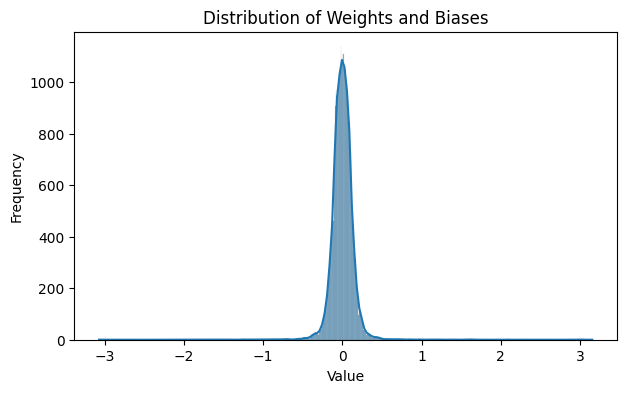

In [ ]:
print(f'Saving to: {checkpoint_path}')

epochs=4
patience = epochs//3
callbacks = [
            tf.keras.callbacks.EarlyStopping(patience=patience, monitor='val_loss'),
            tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, verbose=1, save_best_only=True),
    ]

results = model.fit(train_iterator, 
                    validation_data=val_iterator,
                    epochs=epochs, 
                    callbacks=callbacks)

test_results = model.evaluate(test_iterator)

# Assuming `model` is your trained U-Net model
model_weights = model.get_weights()
all_weights = np.concatenate([w.flatten() for w in model_weights])
import seaborn as sns

# Plotting the histogram
plt.figure(figsize=(7, 4))
sns.histplot(all_weights, bins=900, kde=True)
plt.title('Distribution of Weights and Biases')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from Train1 import train
epochs = 200

train(model, train_iterator, test_iterator, val_iterator, dataset=dataset, segconfig=segconfig , lossname=lossname, CONFIGKEY=CONFIGKEY, epochs=epochs)


# Assuming `model` is your trained U-Net model
model_weights = model.get_weights()
all_weights = np.concatenate([w.flatten() for w in model_weights])
import seaborn as sns

# Plotting the histogram
plt.figure(figsize=(7, 4))
sns.histplot(all_weights, bins=900, kde=True)
plt.title('Distribution of Weights and Biases')
plt.xlabel('Value')
plt.ylabel('Frequency')

2025-06-06 08:43:28.456777
Epoch 1/200


(None, 64, 64, 16)
+ (None, 64, 64, 64, 64, 16)
h1 h2 out (None, 64, 64, 16) (None, 64, 64, 64, 64, 16)


/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_188']. Received: the structure of inputs=*
  warnings.warn(


h2_out shape update (None, 64, 64, 16)
(None, 32, 32, 32)
+ (None, 32, 32, 32, 32, 32)
h1 h2 out (None, 32, 32, 32) (None, 32, 32, 32, 32, 32)
h2_out shape update (None, 32, 32, 32)
(None, 64, 64, 32)
+ (None, 64, 64, 64, 64, 32)
h1 h2 out (None, 64, 64, 32) (None, 64, 64, 64, 64, 32)
h2_out shape update (None, 64, 64, 32)
(None, 64, 64, 16)
+ (None, 64, 64, 64, 64, 16)
h1 h2 out (None, 64, 64, 16) (None, 64, 64, 64, 64, 16)
h2_out shape update (None, 64, 64, 16)
(None, 32, 32, 32)
+ (None, 32, 32, 32, 32, 32)
h1 h2 out (None, 32, 32, 32) (None, 32, 32, 32, 32, 32)
h2_out shape update (None, 32, 32, 32)
(None, 64, 64, 32)
+ (None, 64, 64, 64, 64, 32)
h1 h2 out (None, 64, 64, 32) (None, 64, 64, 64, 64, 32)
h2_out shape update (None, 64, 64, 32)


E0000 00:00:1749179993.646774 3156781 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/dropout_32_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-06-06 08:51:39.043472: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INTERNAL: CUDA error: Error recording CUDA event: CUDA_ERROR_ILLEGAL_ADDRESS: an illegal memory access was encountered
	 [[{{node swap_out_StatefulPartitionedCall/gradient_tape/functional_3_1/nlsi2d_volterra_10_1/convolution_1/Conv2DBackpropFilter_0}}]]
F0000 00:00:1749180099.043670 3157131 conv_2d_gpu.h:506] Non-OK-status: GpuLaunchKernel(ShuffleInTensor3Simple<T, 1, 2, 0>, config.block_count, config.thread_per_block, 0, d.stream(), config.virtual_thread_count, in.data(), combined_dims, out.data())
Status: INTERNAL: an illegal memory access was encountered


: 

2025-06-04 03:12:27.929676
Epoch 1/200
x (None, 32, 32, 1)


/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_214']. Received: the structure of inputs=*
  warnings.warn(


x (None, 32, 32, 2)
x (None, 16, 16, 2)
x (None, 16, 16, 4)
x (None, 8, 8, 4)
x (None, 8, 8, 8)
x (None, 4, 4, 8)
x (None, 4, 4, 16)
x (None, 8, 8, 16)
x (None, 8, 8, 8)
x (None, 16, 16, 8)
x (None, 16, 16, 4)
x (None, 32, 32, 4)
x (None, 32, 32, 2)
x (None, 32, 32, 1)
x (None, 32, 32, 2)
x (None, 16, 16, 2)
x (None, 16, 16, 4)
x (None, 8, 8, 4)
x (None, 8, 8, 8)
x (None, 4, 4, 8)
x (None, 4, 4, 16)
x (None, 8, 8, 16)
x (None, 8, 8, 8)
x (None, 16, 16, 8)
x (None, 16, 16, 4)
x (None, 32, 32, 4)
x (None, 32, 32, 2)
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - IoU: 0.8573 - accuracy: 0.9210 - dice_coef: 0.9027 - loss: 0.2202x (None, 32, 32, 1)
x (None, 32, 32, 2)
x (None, 16, 16, 2)
x (None, 16, 16, 4)
x (None, 8, 8, 4)
x (None, 8, 8, 8)
x (None, 4, 4, 8)
x (None, 4, 4, 16)
x (None, 8, 8, 16)
x (None, 8, 8, 8)
x (None, 16, 16, 8)
x (None, 16, 16, 4)
x (None, 32, 32, 4)
x (None, 32, 32, 2)

Epoch 1: val_loss improved from inf to 0.10632, saving model to 20250604G_ATLAS_nonResidual_bce_con

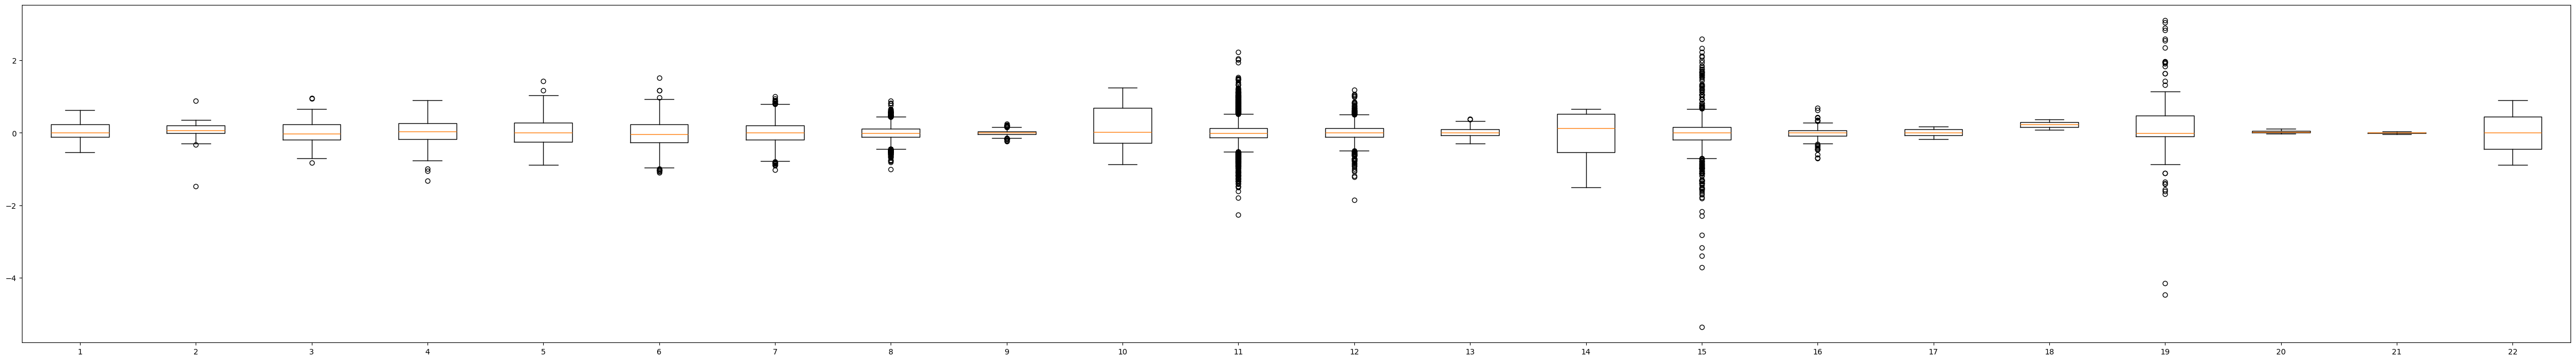

Elapsed time: mm:ss:mss 	 544:51:424


Text(0, 0.5, 'Frequency')

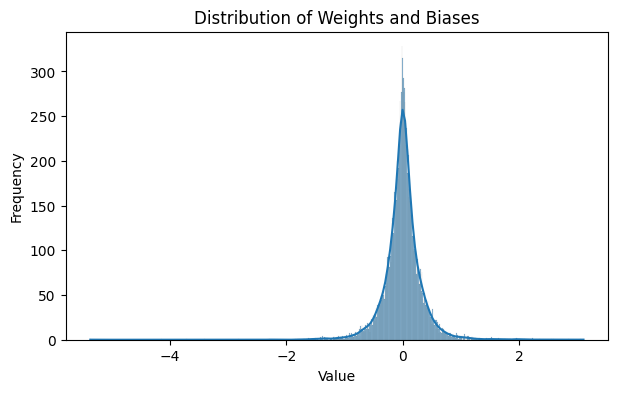

In [ ]:
with tf.GradientTape() as tape:
    y_pred = model(X_batch)
    loss = tf.reduce_mean(tf.square(y_pred - Y_batch))

grads = tape.gradient(loss, model.trainable_variables)
for var, g in zip(model.trainable_variables, grads):
    print(f"{var.name}: {'✅ OK' if g is not None else '❌ No Grad'}")

for var, grad in zip(model.trainable_variables, grad):
    if grad is not None:
        print(f"{var.name}: mean gradient {tf.reduce_mean(tf.abs(grad)):.6f}")
    else:
        print(f"{var.name}: NO GRADIENTS")
del var, grad, g, y_red, loss

/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_109']. Received: the structure of inputs=*
  warnings.warn(


x (20, 32, 32, 1)
x (20, 32, 32, 2)
x (20, 16, 16, 2)
x (20, 16, 16, 4)
x (20, 8, 8, 4)
x (20, 8, 8, 8)
x (20, 4, 4, 8)
x (20, 4, 4, 16)
x (20, 8, 8, 16)
x (20, 8, 8, 8)
x (20, 16, 16, 8)
x (20, 16, 16, 4)
x (20, 32, 32, 4)
x (20, 32, 32, 2)
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
bias: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
bias: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
bias: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
kernel: ✅ OK
bias: ✅ OK


NameError: name 'grad' is not defined

In [ ]:
model_weights = model.get_weights()
[_.shape for _ in model_weights]
[_.dtype for _ in model_weights]

[dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32')]

In [ ]:
a = [_ for _ in model_weights if len(_.shape)>1 and _.shape[0]>1]
[_.shape for _ in a]

[(4, 4, 1, 2),
 (4, 4, 2, 2),
 (4, 4, 2, 4),
 (4, 4, 4, 4),
 (4, 4, 4, 8),
 (4, 4, 8, 8),
 (4, 4, 8, 16),
 (4, 4, 16, 16),
 (2, 2, 8, 16),
 (4, 4, 16, 8),
 (4, 4, 8, 8),
 (2, 2, 4, 8),
 (4, 4, 8, 4),
 (4, 4, 4, 4),
 (2, 2, 2, 4),
 (4, 4, 4, 2),
 (4, 4, 2, 2)]

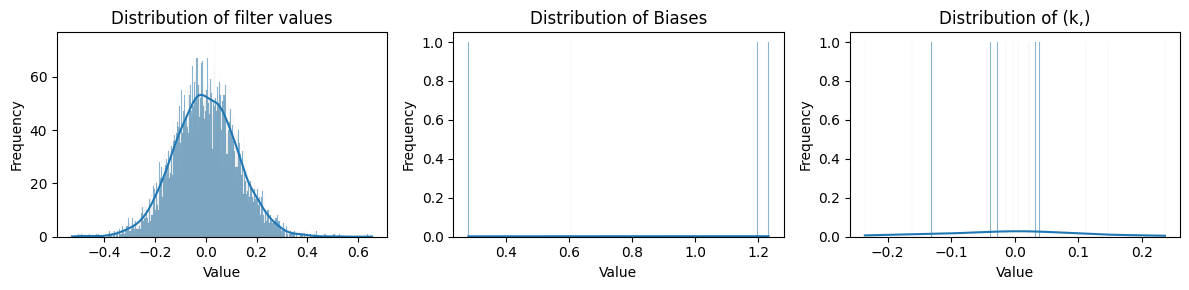

In [ ]:
# Assuming `model` is trained U-Net model
model_weights = model.get_weights()
# a = [_ for _ in model_weights if len(_.shape)>1]
a = [_ for _ in model_weights if len(_.shape)>1 and _.shape[0]>1]
b = [_ for _ in model_weights if len(_.shape)>1 and _.shape[0]==1]
c = [_ for _ in model_weights if len(_.shape)==1]
c
# all_weights = np.concatenate([w.flatten() for w in model_weights])
# all_weights.shape


# Assuming `model` is your trained U-Net model
# model_weights = model.get_weights()
# all_weights = np.concatenate([w.flatten() for w in model_weights])
all_filter_vals = np.concatenate([w.flatten() for w in a])
all_bias1 = np.concatenate([w.flatten() for w in b])
all_bias2 = np.concatenate([w.flatten() for w in c])
import seaborn as sns

# Plotting the histogram
plt.figure(figsize=(12, 3))
plt.subplot(131)
sns.histplot(all_filter_vals, bins=900, kde=True)
plt.title('Distribution of filter values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.subplot(132)
sns.histplot(all_bias1, bins=900, kde=True)
plt.title('Distribution of Biases')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.subplot(133)
sns.histplot(all_bias2, bins=900, kde=True)
plt.title('Distribution of (k,)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
model_weights[2].shape

(4, 4, 2, 4)

In [ ]:
model.weights[0][:,:,0,0]

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[ 0.2892025 ,  0.2737139 ,  0.2566208 ,  0.32468075],
       [ 0.03933683,  0.34708467, -0.25891778, -0.1424253 ],
       [-0.25812405, -0.29516914, -0.27049047, -0.27185947],
       [ 0.07175141, -0.14333013, -0.13265298, -0.17023872]],
      dtype=float32)>

In [ ]:
a[6].shape

(4, 4, 8, 16)

In [ ]:
import math

def next_perfect_square(n):
    root = math.ceil(math.sqrt(n))
    return root ** 2

# Given number
# n = 65

# Find the next perfect square
# next_square = next_perfect_square(n)
# next_square

In [ ]:
[_.shape for _ in a]

[(4, 4, 1, 2),
 (4, 4, 2, 2),
 (4, 4, 2, 4),
 (4, 4, 4, 4),
 (4, 4, 4, 8),
 (4, 4, 8, 8),
 (4, 4, 8, 16),
 (4, 4, 16, 16),
 (2, 2, 8, 16),
 (4, 4, 16, 8),
 (4, 4, 8, 8),
 (2, 2, 4, 8),
 (4, 4, 8, 4),
 (4, 4, 4, 4),
 (2, 2, 2, 4),
 (4, 4, 4, 2),
 (4, 4, 2, 2)]

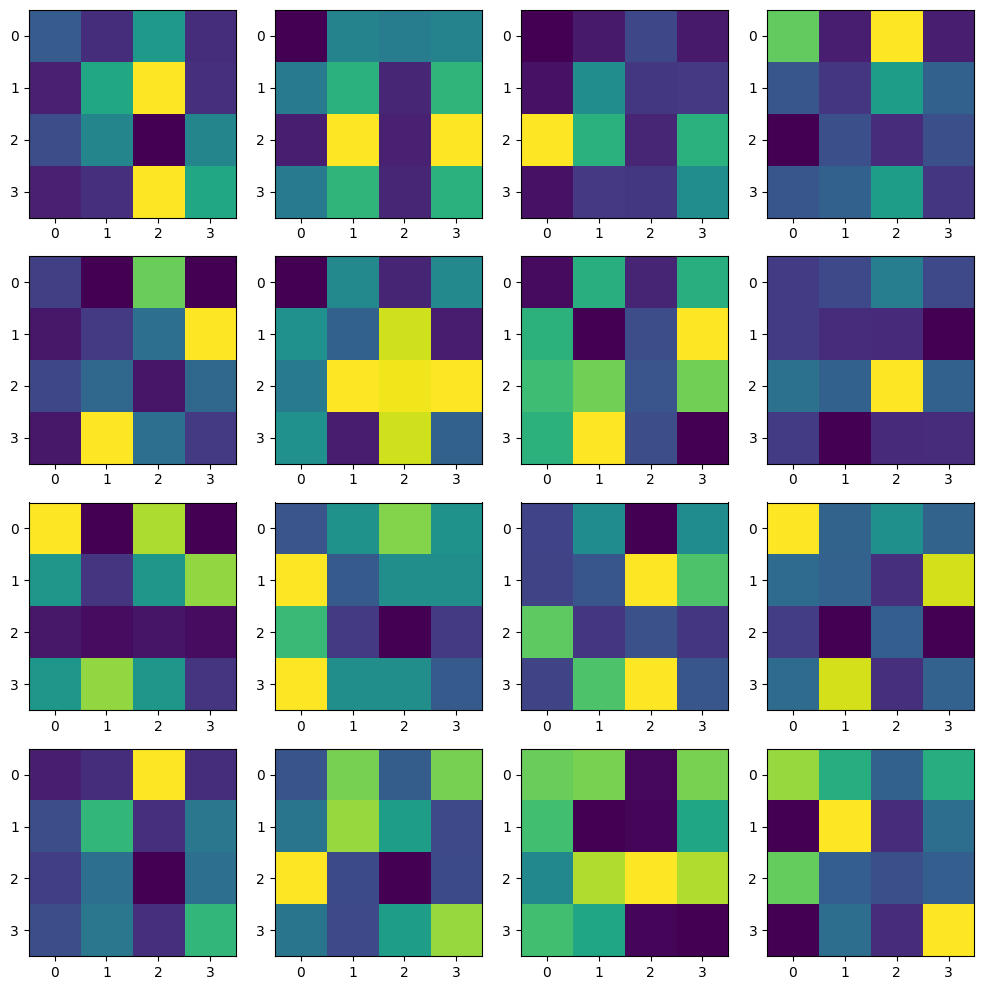

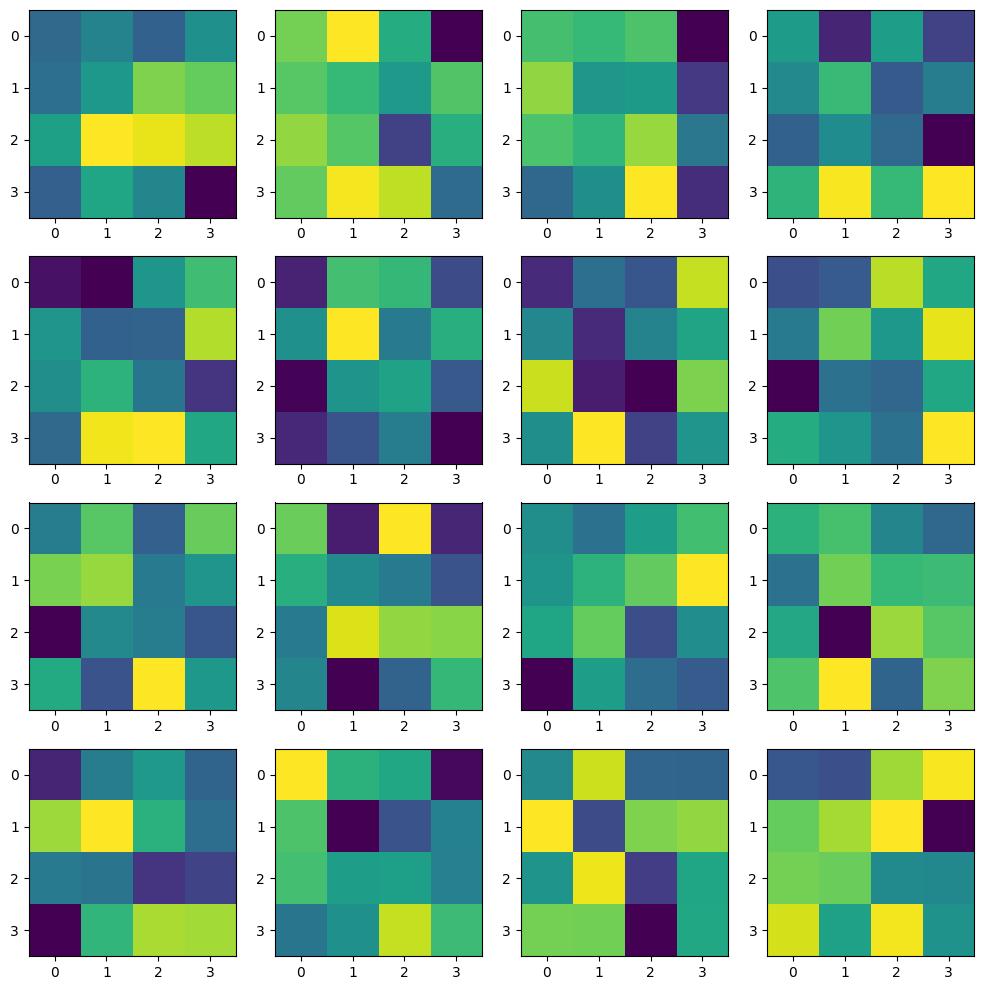

In [ ]:
#MEDCNN plot
idx = 6
ch = 4
_ = a[idx]
grid = int(np.sqrt(next_perfect_square(_.shape[-1])))
plt.figure(figsize=(10,10))
for i in range(_.shape[-1]):
    plt.subplot(grid,grid,i+1)
    # plt.imshow(tf.abs(model.weights[0][:,:,0,i]))
    # plt.imshow(_[:,:,ch,i])#.astype(np.float32))
    plt.imshow(np.abs(np.fft.fftshift(np.fft.fft2(_[:,:,ch,i]))))#.astype(np.float32))
    # plt.imshow(np.angle(np.fft.fft2(_[:,:,1,i])))#.astype(np.float32))
plt.tight_layout()


grid = int(np.sqrt(next_perfect_square(_.shape[-1])))
plt.figure(figsize=(10,10))
for i in range(_.shape[-1]):
    plt.subplot(grid,grid,i+1)
    # plt.imshow(tf.abs(model.weights[0][:,:,0,i]))
    plt.imshow(_[:,:,ch,i])#.astype(np.float32))
    # plt.imshow(np.abs(np.fft.fftshift(np.fft.fft2(_[:,:,ch,i]))))#.astype(np.float32))
    # plt.imshow(np.angle(np.fft.fft2(_[:,:,1,i])))#.astype(np.float32))
plt.tight_layout()

In [ ]:
X_batch, Y_batch = test_iterator.__getitem__(0) 
X_batch.shape, Y_batch.shape

((20, 32, 32, 1), (20, 32, 32, 2))

In [ ]:
yhat = model.predict(X_batch)

/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_214']. Received: the structure of inputs=*
  warnings.warn(


x (20, 32, 32, 1)
x (20, 32, 32, 2)
x (20, 16, 16, 2)
x (20, 16, 16, 4)
x (20, 8, 8, 4)
x (20, 8, 8, 8)
x (20, 4, 4, 8)
x (20, 4, 4, 16)
x (20, 8, 8, 16)
x (20, 8, 8, 8)
x (20, 16, 16, 8)
x (20, 16, 16, 4)
x (20, 32, 32, 4)
x (20, 32, 32, 2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [ ]:
yhat.shape

(20, 32, 32, 2)

(20, 32, 32, 1) (20, 32, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
(20, 32, 32, 2) <<
(20, 32, 32) <<


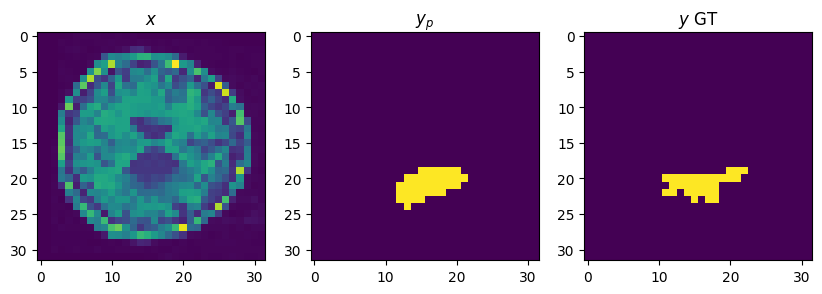

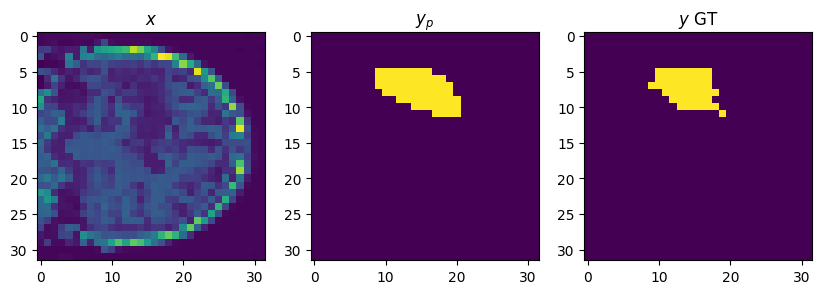

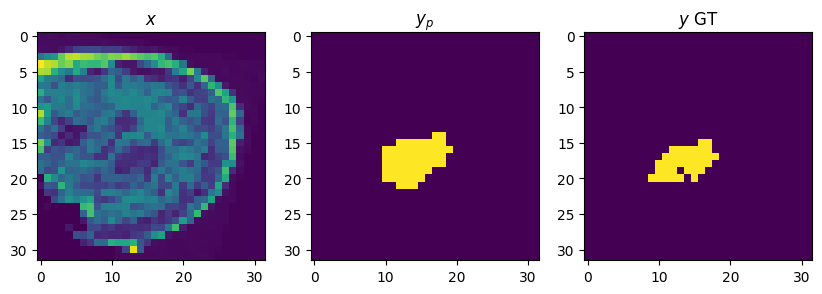

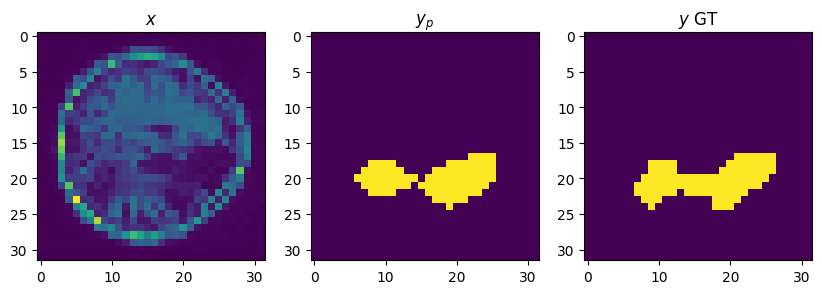

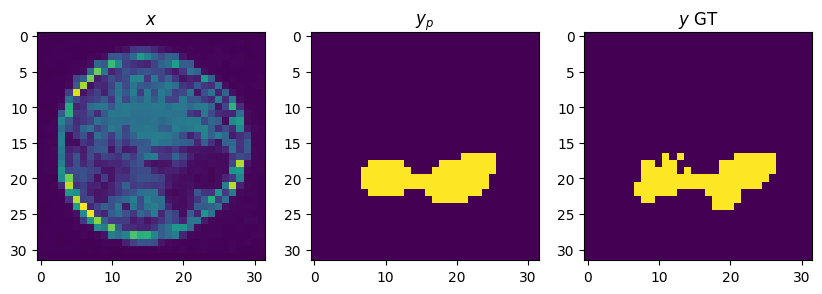

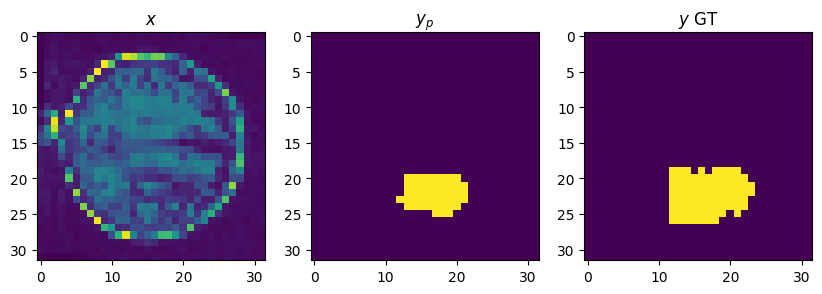

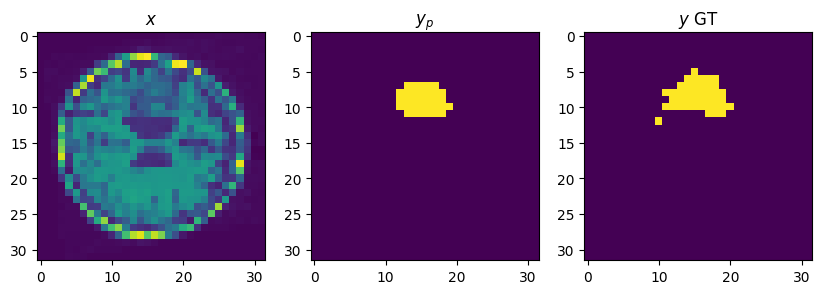

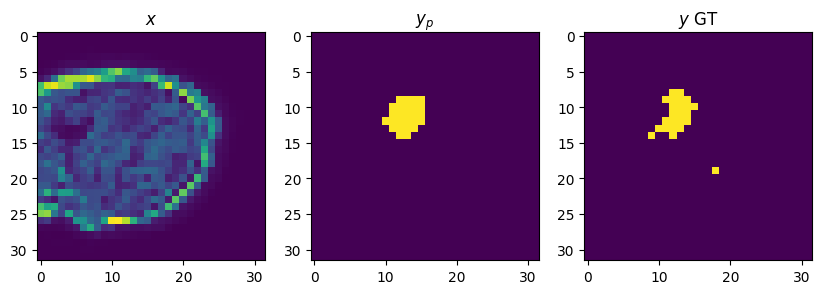

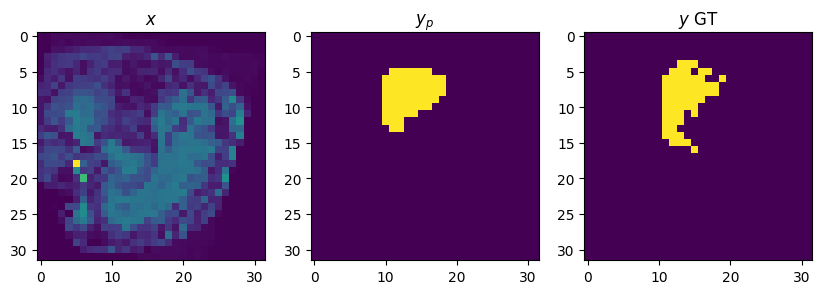

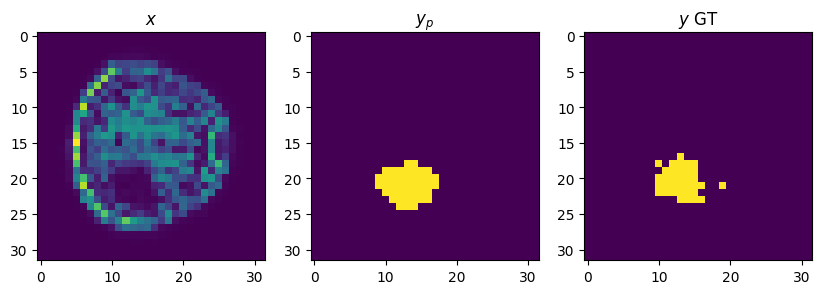

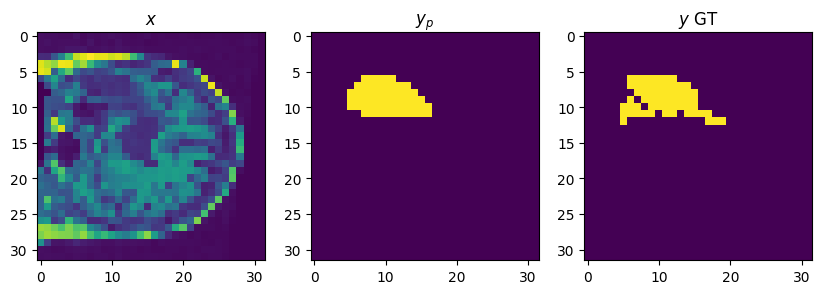

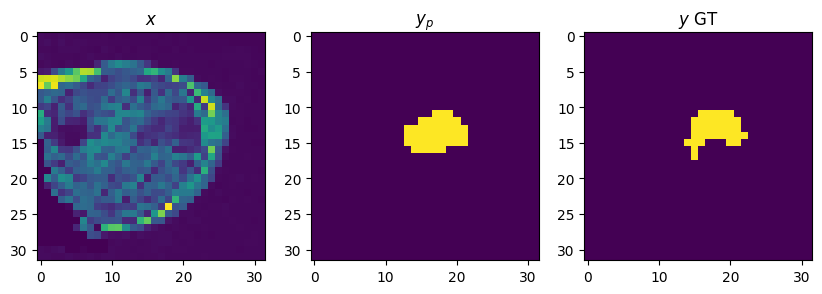

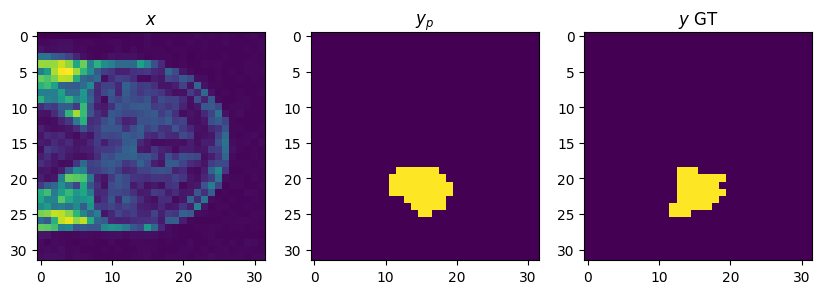

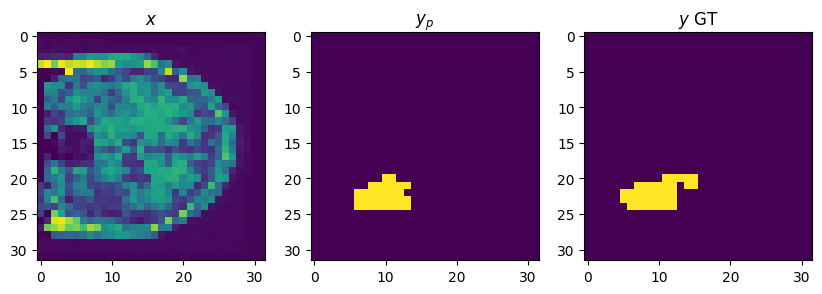

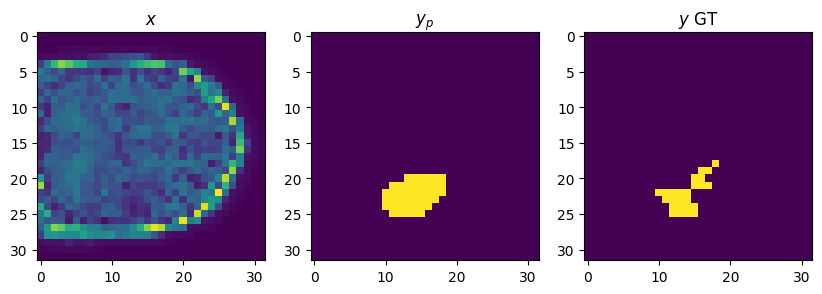

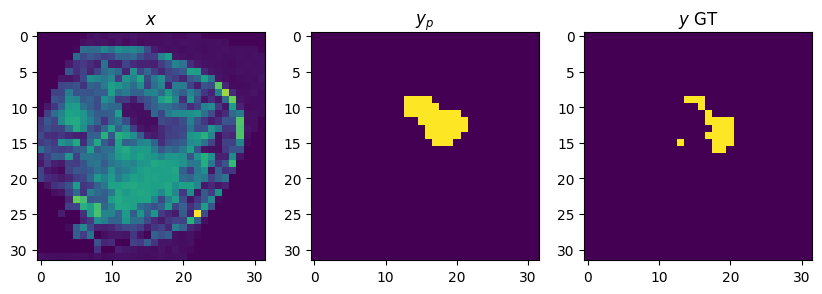

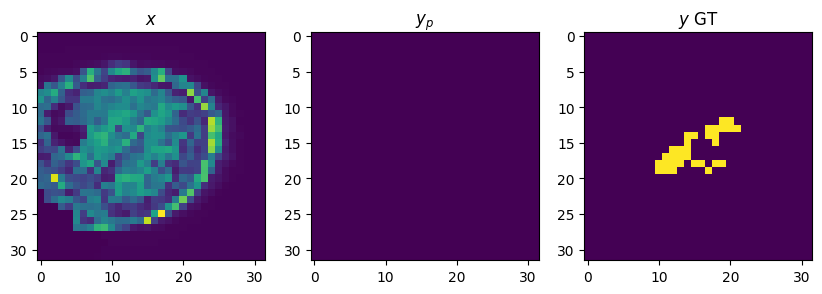

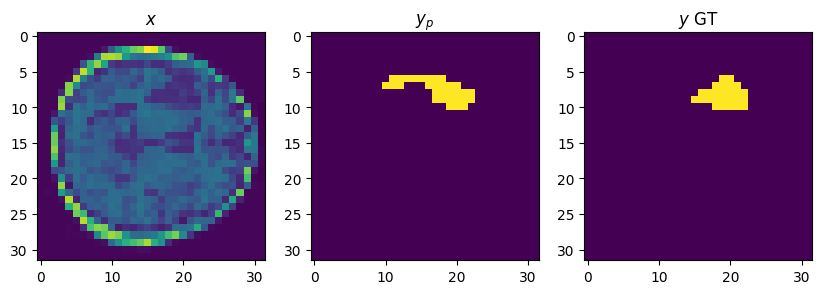

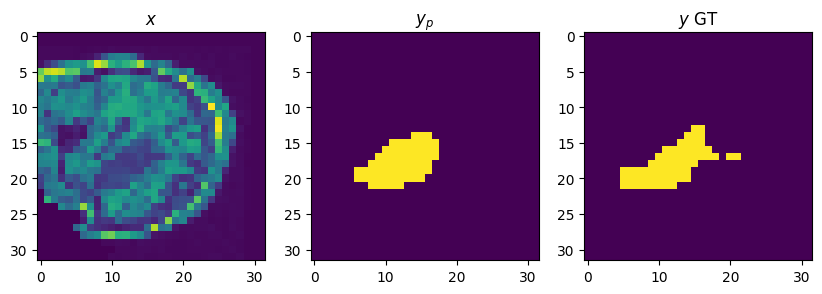

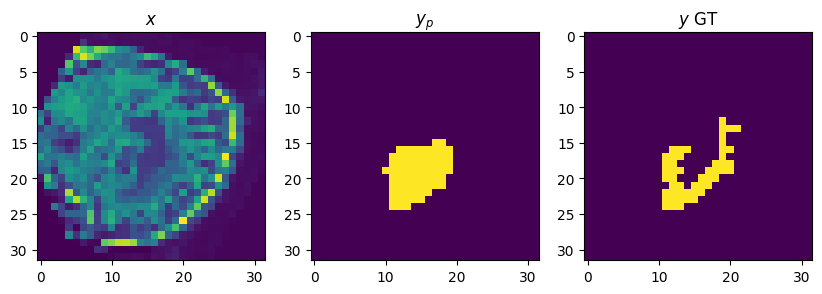

In [ ]:
count=0
for batch in test_iterator:
    a, b = batch
    b = np.argmax(b, axis=-1)
    print(a.shape, b.shape)
    yhat = model.predict(a)
    print(yhat.shape,'<<')
    yhat = np.argmax(yhat, axis=-1)
    print(yhat.shape,'<<')


    for k in range(a.shape[0]):
        plt.figure(figsize=(10,3))
        plt.subplot(131), plt.imshow(a[k,:,:,:]), plt.title('$x$')
        plt.subplot(132), plt.imshow(yhat[k,:,:,]), plt.title('$y_p$')
        plt.subplot(133), plt.imshow(b[k,:,:]), plt.title('$y$ GT')
        plt.show()

    count+=1
    if count == 1:
        break

--

In [ ]:
#%% 
### new with einsum operations
"""Fixed the DWT and IDWT matrix.
The matrix is of same dimension as of the signal. No padding is applied.
Circular convolution takes care of the boundary effects. @KKT 14/03/2024 """

# include ../dirx 
# mylibpath = '/home/k/PLAYGROUND10GB/myDTSPlib'
# mylibpath = '/home/k/PLAYGROUND10GB/kerasDWTLayer1D2D_orthogonal_wavelets.conv/FastDWTConvLayers/pypipackageTFDWT3d'
# import sys
# sys.path.insert(0,mylibpath)
# del mylibpath

import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import scipy
# import pywt
import numpy as np
# print(f"\
#     \n tf {tf.__version__}, \
#     \n matplotlib {matplotlib.__version__} \
#     \n scipy {scipy.__version__}\
#     \n pywavelets {pywt.__version__} (for comparing tf results)")


# def get_A_matrix_dwt_analysisFB_unit(h0,h1,N:int):
#     """returns Analysis Matrix A"""
#     L = len(h0)
#     __H_branch_row = lambda h0,N: np.concatenate((h0, np.zeros(int(N - len(h0)))))
#     __H_start_row = lambda _row: np.roll(_row, shift=-L+2, axis=None)
#     __H_start_row(__H_branch_row(h0,N))
#     __H_branch= lambda _row: [np.roll(_row, shift=k*2, axis=None) for k in range(_row.shape[0])]#-len(h0)+1)]
#     H0 = __H_branch(__H_start_row(__H_branch_row(h0,N)))
#     H1 = __H_branch(__H_start_row(__H_branch_row(h1,N)))
#     return np.concatenate((H0[:int(len(H0)/2)], H1[:int(len(H1)/2)]))

# A = get_A_matrix_dwt_analysisFB_unit(h0,h1,N)
# A.shape, A


## OK
# import pywt
from TFDWT.GETDWTFiltersOrtho import GETDWTFiltersOrtho
from TFDWT.get_A_matrix_dwt_analysisFB_unit import get_A_matrix_dwt_analysisFB_unit
@keras.saving.register_keras_serializable()
class DWT2D(tf.keras.layers.Layer):
    """2D DWT layer @kkt"""
    def __init__(self, wave='haar', **kwargs):
        super(DWT2D, self).__init__(**kwargs)
        w = GETDWTFiltersOrtho(wave)
        self.h0, self.h1 = w.analysis()
        # g0, g1 = w.synthesis()
        self.L = len(self.h0)
        # self.padding_mode = 'symmetric'
        # self.N
        # self.A
        
    def build(self, input_shape):
        self.num_channels = input_shape[-1]
        self.N = input_shape[1]
        self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # self.pw = (self.A.shape[0]-self.N)//2
        super(DWT2D, self).build(input_shape) 
       
    
    def call(self, inputs):
        # ch_ = [self.__pad(inputs[..., i:i+1]) for i in range(self.num_channels)]
        # ch_ = tf.concat(ch_, axis=-1)
        # ch_ = [self.__dwt(ch_[..., i:i+1]) for i in range(self.num_channels)]
        ch_ = [self.__dwt(inputs[..., i:i+1]) for i in range(self.num_channels)]
        out = tf.concat(ch_, axis=-1)
        #
        # out = self.__extract_4subbands(out)
        return out

    @tf.function
    def __dwt(self, x):
        # print('>>',x.shape)
        # x = tf.squeeze(x, axis=-1)
        # _ = tf.transpose(x, perm=[0,2,1])
        # _rowconv_out = tf.cast(self.A, tf.float32)@tf.cast(_, tf.float32)
        # _colconv_out = tf.cast(self.A, tf.float32)@tf.transpose(_rowconv_out, perm=[0,2,1])
        # _LLLHHLHH = _colconv_out
        ## end dwt



        ## einsum code
        _x2d = tf.squeeze(x, axis=-1)
        _x2d = tf.transpose(_x2d,[0,2,1])
        A = tf.cast(self.A, tf.float32)
        _rowconv_out = tf.einsum('ij,bjk->bik', A, _x2d)
        _rowconv_outT = tf.transpose(_rowconv_out,[0,2,1])
        _LLLHHLHH = tf.einsum('ij,bjk->bik', A, _rowconv_outT)
        _colconv_out = _LLLHHLHH
        # _LLLHHLHH.shape
        # plt.imshow(_LLLHHLHH)
        ## einsum code end








        # OK for batch   
        # perm=[1,2,0]#ok but rotate 90
        # __ = tf.cast(self.A, tf.float32)@tf.transpose(_rowconv_out, perm=perm)
       
        # perm=[2,1,0]
        # __ = tf.transpose(__, perm=perm)
        # print('*T',__.shape)
        
        # plt.imshow(__[1,:,:]), plt.show()
        # plt.imshow(__[0,:,:]), plt.show()
        # return __
        return tf.expand_dims(_colconv_out, axis=-1)

    # def __pad(self, x):
    #     x = tf.squeeze(x, axis=-1)
    #     paddings = tf.constant([[0,0], [self.pw, self.pw,], [self.pw, self.pw]])

    #     x_padded = tf.pad(x, paddings, self.padding_mode)
    #     # print('+',x_padded.shape) 
    #     # return x_padded
    #     return tf.expand_dims(x_padded, axis=-1)

    def __extract_4subbands(self,LLLHHLHH):
        """returns 4 image subbands LL, LH, HL, HH from DWT Analysis bank o/p --@k"""
        # global N
        _mid = int(LLLHHLHH.shape[1]/2)
        LL = LLLHHLHH[:,:_mid,:_mid,:]
        LH = LLLHHLHH[:,_mid:,:_mid,:]
        HL = LLLHHLHH[:,:_mid,_mid:,:]
        HH = LLLHHLHH[:,_mid:,_mid:,:]
        # _i = int((LL.shape[1] - self.N/2)/2)
        # out = tf.concat([LL[:,_i:-_i,_i:-_i,:], LH[:,_i:-_i,_i:-_i,:], HL[:,_i:-_i,_i:-_i,:], HH[:,_i:-_i,_i:-_i,:]], axis=-1)
        out = tf.concat([LL, LH, HL, HH], axis=-1)
        return out

    # def compute_output_shape(self, input_shape):
    #     batch_size, height, width, channels = input_shape
    #     new_height, new_width = height // 2, width // 2
    #     return (batch_size, new_height, new_width, 4 * channels)
    
    def get_config(self):
        config = super(DWT2D, self).get_config()
        return config



# ## WORKING IDWT similar to wavetf
# import pywt
# from GETDWTFiltersOrtho import GETDWTFiltersOrtho
@keras.saving.register_keras_serializable()
class IDWT2D(tf.keras.layers.Layer):
    """2D IDWT layer @kkt"""
    def __init__(self, wave='haar', **kwargs):
        super(IDWT2D, self).__init__(**kwargs)
        w = GETDWTFiltersOrtho(wave)
        if 'bior' in wave or 'rbio' in wave:
            """BIORTHOGONAL wavelets"""
            # self.g0, self.g1 = w.synthesis()
            # self.h0, self.h1 = self.g0, self.g1
            # del self.g0, self.g1
            self.h0, self.h1 = w.synthesis()
            # self.biortho_flag = 1
            # print(f"Biothogonal wavelet {wave}")
        else:
            """ORTHOGONAL wavelets"""
            self.h0, self.h1 = w.analysis()
        # g0, g1 = w.synthesis()
        self.L = len(self.h0)
        # self.padding_mode = 'symmetric'

    def build(self, input_shape):
        self.num_channels = input_shape[-1]
        self.N = int(input_shape[1])
        self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # self.pw = int(self.L/2)
        super(IDWT2D, self).build(input_shape) 

    def call(self, inputs):
        # self.N = int(inputs.shape[1]*2)
        # self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # input_shape = tf.shape(inputs)

        #all input channels
        # ch_ = tf.unstack(inputs, axis=-1)
        # print(len(ch_))
        # ch_ = tf.stack([self.__pad(_) for _ in ch_], axis=-1)
        # __ = self.__splitch_for_idwt(ch_)
        # __ = self.__splitch_for_idwt(inputs)
        # __ = [self.__rejoin(_) for _ in __]# axis=-1)

        # out = tf.stack([self.__idwt(_) for _ in __], axis=-1)

        ch_ = [self.__idwt(inputs[..., i:i+1]) for i in range(self.num_channels)]
        # print('+', h_[0].shape)
        out = tf.stack(ch_, axis=-1)
        # out = ch_
        # L = self.L
        return out#[:,L:-L,L:-L,:]

    @tf.function
    def __idwt(self, x_dwtcoeffs):
        # __ = x_dwtcoeffs
        # _r = tf.transpose(__, perm=[0,2,1])
        # _r = tf.cast(self.A.T, tf.float32) @ _r
        # ans = self.A.T@tf.transpose(_r,perm=[0,2,1])
        # # print('*', ans.shape)
        # # plt.imshow(ans[0,:,:]), plt.show()
        # return ans#[L:-L,L:-L,:]
        x_dwtcoeffs = tf.squeeze(x_dwtcoeffs, axis=-1)
        _LLLHHLHH = x_dwtcoeffs
        A = tf.cast(self.A, tf.float32)
        # print('>',x_dwtcoeffs.shape)
        
        _ = tf.transpose(_LLLHHLHH,[0,2,1])
        # print('>>', _.shape)
        _AT = tf.cast(tf.transpose(A,[1,0]), dtype=tf.float32)
        # print('>>',_AT.shape, _.shape)
        _r = tf.einsum('ij,bjk->bik', _AT, _)
        _rT = tf.transpose(_r,[0,2,1])
        _r = tf.einsum('ij,bjk->bik', _AT, _rT)
        # plt.imshow(_r)
        # _LLLHHLHH.dtype, _AT.dtype, _r.shape
        # print('+>',_r.shape)
        return _r
        
    
    # def __pad(self, x):
    #     paddings = tf.constant([[0,0], [self.pw, self.pw,], [self.pw, self.pw]])
    #     x_padded = tf.pad(x, paddings, self.padding_mode)
    #     # print('+',x_padded.shape) 
    #     return x_padded

    def __splitch_for_idwt(self,x):
        w = int(x.shape[-1]/4)
        __ = [tf.stack([x[:,:,:,k], x[:,:,:,k+1*w], x[:,:,:,k+2*w], x[:,:,:,k+3*w]],  axis=-1) for k in range(w)]
        return __
    #__ = __splitch_for_idwt(coeffs)

    def __rejoin(self,subbands):
        el = tf.unstack(subbands, axis=-1)
        _1 = tf.concat([el[0][:,:,:], el[2][:,:,:]], axis=-1)
        _1.shape
        _2 = tf.concat([el[1][:,:,:], el[3][:,:,:]], axis=-1)
        _1.shape
        _ = tf.concat([_1, _2], axis=-2)
        _.shape
        return _
    #tf.stack([rejoin(_) for _ in __], axis=-1)

    # def compute_output_shape(self, input_shape):
    #     batch_size, height, width, channels = input_shape
    #     new_height, new_width, new_channels = height *2, width *2, channels //4
    #     return (batch_size, new_height, new_width, new_channels)
   
    def get_config(self):
        config = super(IDWT2D, self).get_config()
        return config
    